# Extended Data Figure 7

Kexin Dong

Barcode counts and bottleneck analysis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

## 7a

Histogram of gRNA counts for individual samples from ABE subpool of MBESv2. S, spleen; B, bone marrow; M, meninges.

In [ ]:
a = list(bc_df_cbe_normed.columns)

n = ['S REP1', 'S REP2', 'S REP3', 'S REP4', 'S REP5', 'S REP6',
'S REP7', 'S REP8', 'S REP9', 'B REP1', 'B REP2',
'B REP3', 'B REP4', 'B REP5', 'B REP6',
'B REP7', 'B REP8', 'B REP9', 'B REP10',
'M REP1', 'M REP2', 'M REP3', 'M REP4', 'M REP5',
'M REP6', 'M REP7', 'M REP8', 'M REP9', 'M REP10',
'INPUT REP1', 'INPUT REP2', 'INPUT REP3', 'D5 REP1', 'D5 REP2',
'D5 REP3', 'D15 REP1', 'D15 REP2', 'D15 REP3', 'PLASMID']

name_dict = dict(zip(a,n))

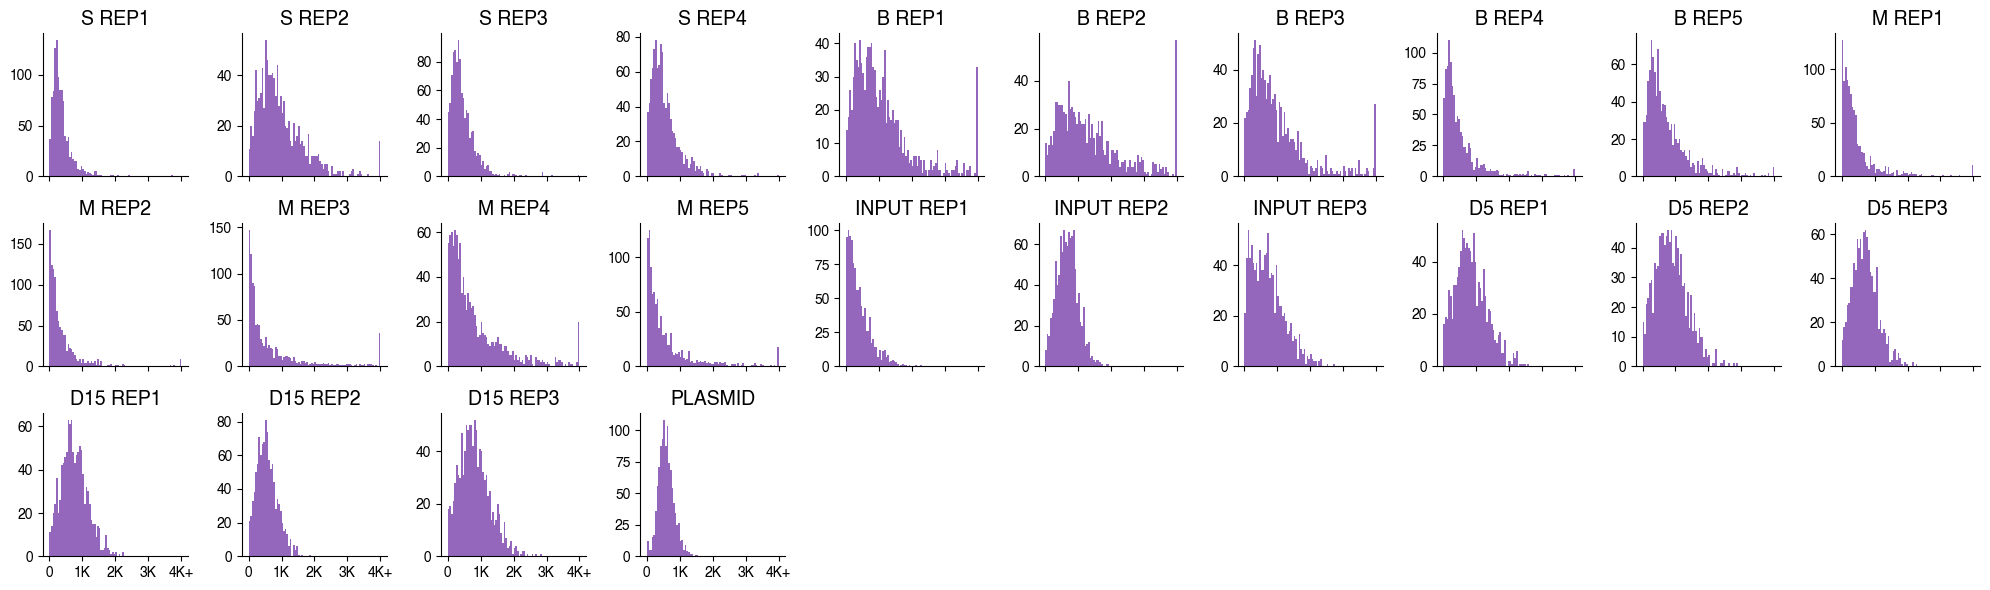

In [ ]:
fig, ax = plt.subplots(3,10,figsize=(20,6), sharey=False, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(bc_df_abe.columns):
            samp = list(bc_df_abe.columns)[num_samp]
            bins=np.linspace(0,4000, 81)
            ax[i][k].hist(np.clip(bc_df_abe[samp], bins[0], bins[-1]), bins=bins,color='tab:purple', edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(name_dict[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([0,1000,2000,3000,4000])
            ax[i][k].set_xticklabels(['0','1K','2K','3K','4K+'])
            #ax.hist[]

for i in range(4,10):
    fig.delaxes(ax[2][i])

fig.tight_layout()
#fig.savefig('figures/extended_3a.pdf')

## 7b

Histogram of gRNA counts for individual samples from CBE subpool of MBESv2. S, spleen; B, bone marrow; M, meninges.

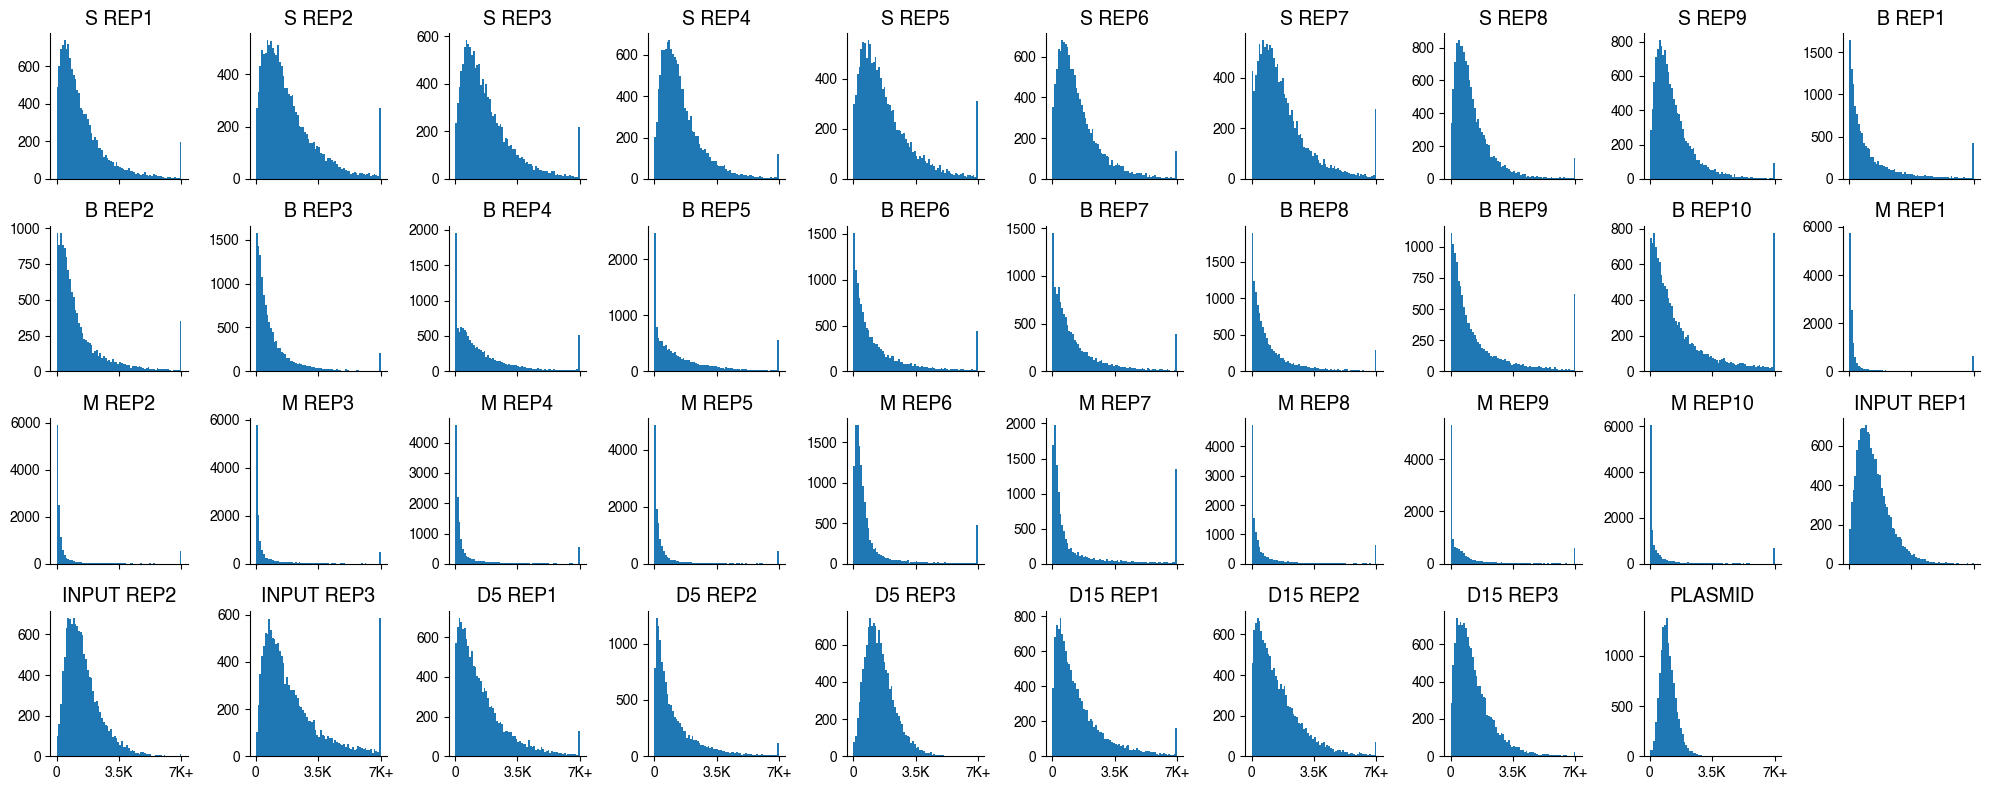

In [ ]:
fig, ax = plt.subplots(4,10,figsize=(20,8), sharey=False, sharex=True)

for i in range(4):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(bc_df_cbe.columns):
            samp = list(bc_df_cbe.columns)[num_samp]
            bins=np.linspace(0,7000, 71)
            ax[i][k].hist(np.clip(bc_df_cbe[samp], bins[0], bins[-1]), bins=bins,edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(name_dict[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([0,3500,7000])
            ax[i][k].set_xticklabels(['0','3.5K','7K+'])
            #ax.hist[]

fig.delaxes(ax[3][9])

fig.tight_layout()
#fig.savefig('figures/extended_3b.pdf')

## 7c

Bubble plot of the percentage of total sequencing reads assigned to a given gRNA for the top 50 represented gRNAs in each sample in the ABE subpool.

## Gini Coefficient

In [ ]:
ABE_counts = pd.read_csv('counts/og/OG_ABE_COUNTS.txt', sep='\t')
CBE_counts = pd.read_csv('counts/og/OG_CBE_COUNTS.txt', sep='\t')

CBE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5','spleen6','spleen7','spleen8','spleen9'],
'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5','bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10'],
'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5','meninges6','meninges7','meninges8','meninges9','meninges10',],
'd5':['d5_rep1','d5_rep2','d5_rep3'],
'd15':['d15_rep1','d15_rep2','d15_rep3'],
'plasmid_lib':['plasmidlib']}

ABE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4'],
'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5'],
'd5':['d5_rep1','d5_rep2','d5_rep3'],
'd15':['d15_rep1','d15_rep2','d15_rep3'],
'plasmid_lib':['plasmidlib']}

In [ ]:
def gini(x):
    #SOURCE: https://stackoverflow.com/questions/39512260/calculating-gini-coefficient-in-python-numpy
    # (Warning: This is a concise implementation, but it is O(n**2)
    # in time and memory, where n = len(x).  *Don't* pass in huge
    # samples!)

    # Mean absolute difference
    mad = np.abs(np.subtract.outer(x, x)).mean()
    # Relative mean absolute difference
    rmad = mad/np.mean(x)
    # Gini coefficient
    g = 0.5 * rmad
    return g

In [ ]:
CBE_samps = list(CBE_counts.columns[2:])
ABE_samps = list(ABE_counts.columns[2:])

CBE_skew = []
ABE_skew = []
for i in CBE_samps:
    d = sorted(np.asarray(CBE_counts[i]))
    g = gini(d)
    CBE_skew.append(g)

for i in ABE_samps:
    d = sorted(np.asarray(ABE_counts[i]))
    g = gini(d)
    ABE_skew.append(g)

CBE_skew_df = pd.DataFrame(dict(zip(['Sample', 'Gini Coefficient'], [CBE_samps, CBE_skew])))
ABE_skew_df = pd.DataFrame(dict(zip(['Sample', 'Gini Coefficient'], [ABE_samps, ABE_skew])))


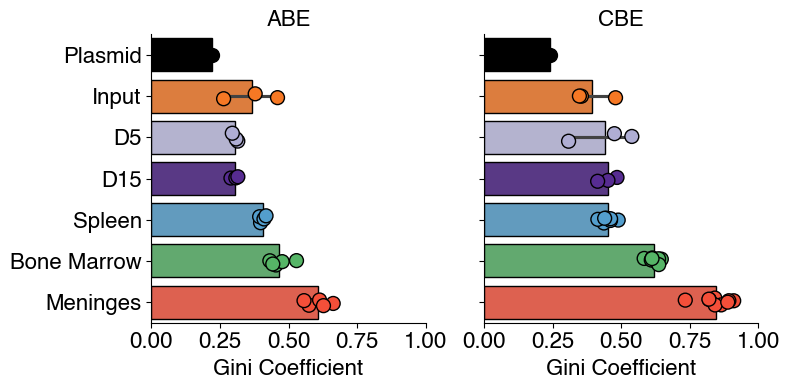

In [ ]:
blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')

ax_dict_CBE = dict(zip(['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6',
       'spleen7', 'spleen8', 'spleen9', 'bonemarrow1', 'bonemarrow2',
       'bonemarrow3', 'bonemarrow4', 'bonemarrow5', 'bonemarrow6',
       'bonemarrow7', 'bonemarrow8', 'bonemarrow9', 'bonemarrow10',
       'meninges1', 'meninges2', 'meninges3', 'meninges4', 'meninges5',
       'meninges6', 'meninges7', 'meninges8', 'meninges9', 'meninges10',
       'input_rep1', 'input_rep2', 'input_rep3', 'd5_rep1', 'd5_rep2',
       'd5_rep3', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'plasmidlib'], 
       [4,4,4,4,4,4,4,4,4,
        5,5,5,5,5,5,5,5,5,5,
        6,6,6,6,6,6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0]))

ax_dict_ABE = dict(zip(['spleen1', 'spleen2', 'spleen3', 'spleen4', 
          'bonemarrow1','bonemarrow2', 'bonemarrow3', 'bonemarrow4', 'bonemarrow5',
            'meninges1','meninges2', 'meninges3', 'meninges4', 'meninges5',
              'input_rep1', 'input_rep2', 'input_rep3',
                'd5_rep1', 'd5_rep2', 'd5_rep3', 
                'd15_rep1','d15_rep2', 'd15_rep3', 
                'plasmidlib'], 
       [4,4,4,4,
        5,5,5,5,5,
        6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0]))

d2 = dict(zip([0,1,2,3,4,5,6],['Plasmid', 'Input','D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

CBE_name = []
ABE_name = []
for i, val in CBE_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_CBE[s]
    s3 = d2[s2]
    CBE_name.append(s3)

for i, val in ABE_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_ABE[s]
    s3 = d2[s2]
    ABE_name.append(s3)

ABE_skew_df['Name'] = ABE_name
CBE_skew_df['Name'] = CBE_name


fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order=['Plasmid', 'Input', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

sns.barplot(data = ABE_skew_df, y='Name', x='Gini Coefficient', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
sns.barplot(data = CBE_skew_df, y='Name', x='Gini Coefficient', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)

sns.stripplot(data = ABE_skew_df, y='Name', x='Gini Coefficient', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
sns.stripplot(data = CBE_skew_df, y='Name', x='Gini Coefficient', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_xlim(0,1)

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('ABE', fontsize=16)
ax[1].set_title('CBE', fontsize=16)
ax[0].set_xlabel('Gini Coefficient', fontsize=16)
ax[1].set_xlabel('Gini Coefficient', fontsize=16)

fig.tight_layout()
fig.savefig('figures_final/gini.pdf', transparent=True)

## 7d

Same as (c), but for the CBE subpool.

## 7e

Gini coefficients calculated for all samples in the ABE (left) and CBE (right) subpools.

In [ ]:
samp_CBE = ['D24-12799-6840R_guide_split_BARCODES',
 'D24-12800-6840R_guide_split_BARCODES',
 'D24-12801-6840R_guide_split_BARCODES',
 'D24-12802-6840R_guide_split_BARCODES',
 'D24-12803-6840R_guide_split_BARCODES',
 'D24-12804-6840R_guide_split_BARCODES',
 'D24-12805-6840R_guide_split_BARCODES',
 'D24-12806-6840R_guide_split_BARCODES',
 'D24-12807-6840R_guide_split_BARCODES',
 'D24-12808-6840R_guide_split_BARCODES',
 'D24-12809-6840R_guide_split_BARCODES',
 'D24-12810-6840R_guide_split_BARCODES',
 'D24-12811-6840R_guide_split_BARCODES',
 'D24-12812-6840R_guide_split_BARCODES',
 'D24-12813-6840R_guide_split_BARCODES',
 'D24-12814-6840R_guide_split_BARCODES',
 'D24-12815-6840R_guide_split_BARCODES',
 'D24-12816-6840R_guide_split_BARCODES',
 'D24-12817-6840R_guide_split_BARCODES',
 'D24-12818-6840R_guide_split_BARCODES',
 'D24-12819-6840R_guide_split_BARCODES',
 'D24-12820-6840R_guide_split_BARCODES',
 'D24-12821-6840R_guide_split_BARCODES',
 'D24-12822-6840R_guide_split_BARCODES',
 'D24-12823-6840R_guide_split_BARCODES',
 'D24-12824-6840R_guide_split_BARCODES',
 'D24-12825-6840R_guide_split_BARCODES',
 'D24-12826-6840R_guide_split_BARCODES',
 'D24-12827-6840R_guide_split_BARCODES',
 'D24-12828-6840R_guide_split_BARCODES',
 'D24-12829-6840R_guide_split_BARCODES',
 'D24-12830-6840R_guide_split_BARCODES',
 'D24-12831-6840R_guide_split_BARCODES',
 'D24-12832-6840R_guide_split_BARCODES',
 'D24-12833-6840R_guide_split_BARCODES',
 'D24-12834-6840R_guide_split_BARCODES',
 'D24-12835-6840R_guide_split_BARCODES',
 'D24-12836-6840R_guide_split_BARCODES',
 'D24-12837-6840R_guide_split_BARCODES']

sample_id_CBE = ['spleen1', 'spleen2','spleen3','spleen4','spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'bonemarrow1','bonemarrow2','bonemarrow3',
            'bonemarrow4','bonemarrow5', 'bonemarrow6','bonemarrow7','bonemarrow8', 'bonemarrow9',
             'bonemarrow10','meninges1','meninges2','meninges3','meninges4','meninges5', 'meninges6', 'meninges7',
             'meninges8', 'meninges9', 'meninges10',
            'input_rep1', 'input_rep2', 'input_rep3', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'd15_rep1',
            'd15_rep2', 'd15_rep3', 'plasmidlib']


samp_ABE = ['D24-12774-6848T_guide_split_BARCODES',
 'D24-12775-6848T_guide_split_BARCODES',
 'D24-12776-6848T_guide_split_BARCODES',
 'D24-12777-6848T_guide_split_BARCODES',
 'D24-12778-6848T_guide_split_BARCODES',
 'D24-12779-6848T_guide_split_BARCODES',
 'D24-12780-6848T_guide_split_BARCODES',
 'D24-12781-6848T_guide_split_BARCODES',
 'D24-12782-6848T_guide_split_BARCODES',
 'D24-12783-6848T_guide_split_BARCODES',
 'D24-12784-6848T_guide_split_BARCODES',
 'D24-12785-6848T_guide_split_BARCODES',
 'D24-12786-6848T_guide_split_BARCODES',
 'D24-12787-6848T_guide_split_BARCODES',
 'D24-12788-6848T_guide_split_BARCODES',
 'D24-12789-6848T_guide_split_BARCODES',
 'D24-12790-6848T_guide_split_BARCODES',
 'D24-12791-6848T_guide_split_BARCODES',
 'D24-12792-6848T_guide_split_BARCODES',
 'D24-12793-6848T_guide_split_BARCODES',
 'D24-12794-6848T_guide_split_BARCODES',
 'D24-12795-6848T_guide_split_BARCODES',
 'D24-12796-6848T_guide_split_BARCODES',
 'D24-12797-6848T_guide_split_BARCODES',
 'D24-12798-6848T_guide_split_BARCODES',]

sample_id_ABE = ['spleen1', 'spleen2','spleen3','spleen4','spleen5', 'bonemarrow1','bonemarrow2','bonemarrow3',
            'bonemarrow4','bonemarrow5','meninges1','meninges2','meninges3','meninges4','meninges5',
            'input_rep1', 'input_rep2', 'input_rep3', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'd15_rep1',
            'd15_rep2', 'd15_rep3', 'plasmidlib']


ABE_samples = pd.DataFrame(dict(zip(['file_name', 'sample'], [samp_ABE, sample_id_ABE])))
CBE_samples = pd.DataFrame(dict(zip(['file_name', 'sample'], [samp_CBE, sample_id_CBE])))

ABE_samp_dict = dict(zip(samp_ABE, sample_id_ABE))
CBE_samp_dict = dict(zip(samp_CBE, sample_id_CBE))

In [ ]:
#ABE
df_holder_counts_ABE = []
for key in ABE_samp_dict.keys():

    gg = pd.read_csv(f'240807Hem_ABE/counts/{key}_count_df.csv')
    df_holder_counts_ABE.append(gg)

count_dict_ABE = dict(zip(ABE_samp_dict.values(), df_holder_counts_ABE))

#CBE
df_holder_counts_CBE = []
for key in CBE_samp_dict.keys():

    gg = pd.read_csv(f'240807HemA_CBE/counts/{key}_count_df.csv')
    df_holder_counts_CBE.append(gg)

count_dict_CBE = dict(zip(CBE_samp_dict.values(), df_holder_counts_CBE))

MBES = pd.read_csv('MBESv2_CORRECTED.csv')
MBES = MBES.rename(columns = {'gRNA_id':'Guide_ID'})
ABE_pool_guides = list(MBES[MBES['Pool']=='F1-R1']['Guide_ID'])
CBE_pool_guides = list(MBES[MBES['Pool']=='F2-R2']['Guide_ID'])


names = []
bc_count = []
guide_count = []
#guide_id = []
guide_id_cbe = []
for i in list(count_dict_CBE.keys()):


    names.append(i)
    d = count_dict_CBE[i]
    d = d[d['Guide_ID'].isin(CBE_pool_guides)]

    bc_count.append(list(d['bc_count']))
    
    guide_count.append(list(d['matched_guide_count']))
    guide_id_cbe.append(list(d['Guide_ID']))

bc_df_cbe = pd.DataFrame(dict(zip(names, bc_count)))
guide_df_cbe = pd.DataFrame(dict(zip(names, guide_count)))


names = []
bc_count = []
guide_count = []
guide_id_abe = []
for i in list(count_dict_ABE.keys()):

    if i=='spleen5':
        continue
    else:
        names.append(i)
        d = count_dict_ABE[i]
        d = d[d['Guide_ID'].isin(ABE_pool_guides)]

        bc_count.append(list(d['bc_count']))
        guide_count.append(list(d['matched_guide_count']))
        guide_id_abe.append(list(d['Guide_ID']))

bc_df_abe = pd.DataFrame(dict(zip(names, bc_count)))
guide_df_abe = pd.DataFrame(dict(zip(names, guide_count)))

In [ ]:
bc_df_cbe_normed = bc_df_cbe.copy()
bc_df_abe_normed = bc_df_abe.copy()

for i, val in enumerate(list(bc_df_cbe_normed.columns)):

    sum1 = sum(bc_df_cbe_normed[val])
    bc_df_cbe_normed[val] = 100*(bc_df_cbe_normed[val]/sum1)


for i, val in enumerate(list(bc_df_abe_normed.columns)):

    sum1 = sum(bc_df_abe_normed[val])
    bc_df_abe_normed[val] = 100*(bc_df_abe_normed[val]/sum1)

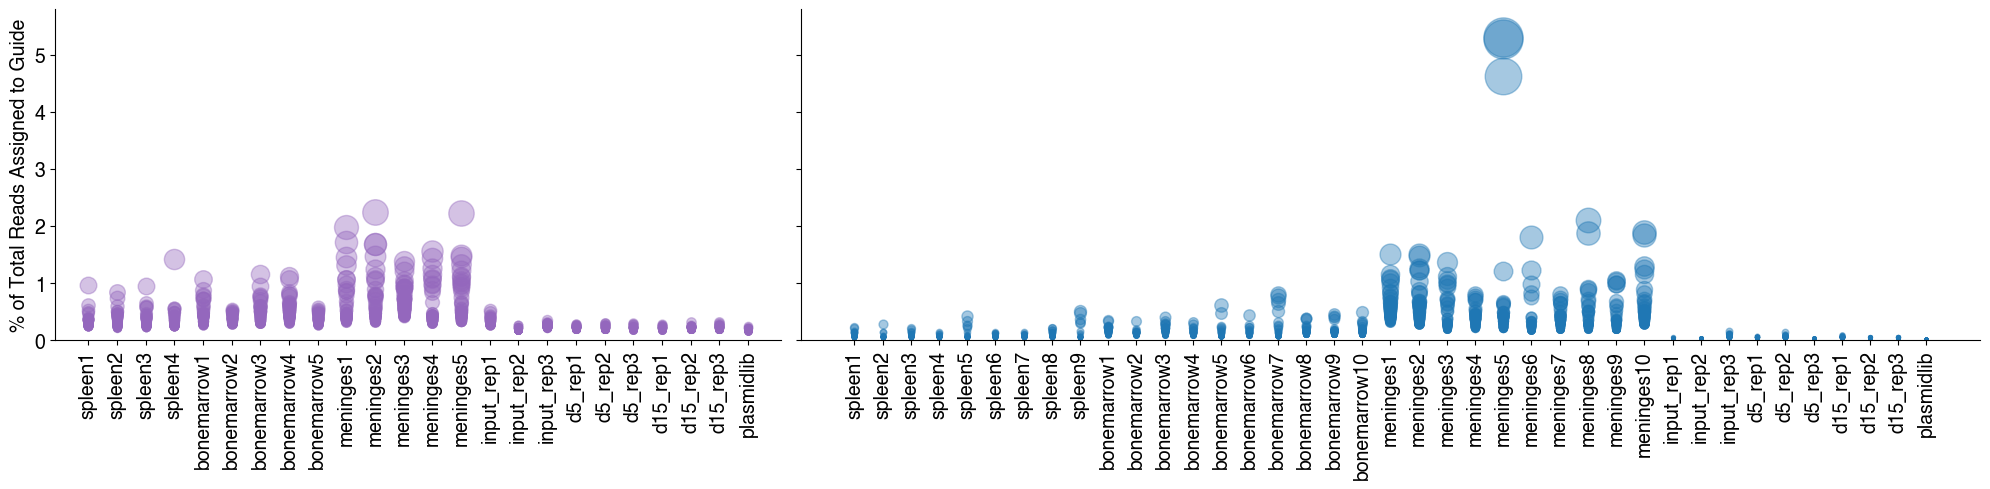

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(20,5), sharey=True, width_ratios=[len(bc_df_abe_normed.columns), len(bc_df_cbe_normed.columns)])
for i, val in enumerate(list(bc_df_abe_normed.columns)):
    top_hits = sorted(bc_df_abe_normed[val])[::-1]
    to_plot = top_hits[:50]

    for j in to_plot:
        ax[0].scatter([i], [j], s=j*150, color='tab:purple', alpha=.4)

ax[0].set_xticks(range(len(bc_df_abe_normed.columns)));
ax[0].set_xticklabels(bc_df_abe_normed.columns, rotation=90);

for i, val in enumerate(list(bc_df_cbe_normed.columns)):
    top_hits = sorted(bc_df_cbe_normed[val])[::-1]
    to_plot = top_hits[:50]

    for j in to_plot:
        ax[1].scatter([i], [j], s=j*150, color='tab:blue', alpha=.4)

ax[1].set_xticks(range(len(bc_df_cbe_normed.columns)));
ax[1].set_xticklabels(bc_df_cbe_normed.columns, rotation=90);


ax[0].set_ylabel('% of Total Reads Assigned to Guide', fontsize=14)
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=14,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=14,)
ax[0].set_ylim(0,5.8)
fig.tight_layout()
#fig.savefig('figures/extended_3cd.pdf')